In [145]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score # métrica de evaluación
from sklearn.metrics import classification_report


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS
from sklearn.feature_selection import SequentialFeatureSelector, RFECV, SelectFromModel
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import time
import joblib
from sklearn import set_config
from lcode import MCFeatureEngineer, get_bmi, get_AST_ALT_Ratio, get_eyesight_mean, get_TG_HDL_Ratio, get_MAP, get_Non_HDL_Cholesterol, get_Pulse_Pressure, get_WHtR
from lcode import CollinearityDropper
set_config(transform_output="pandas")

Primero el dataset para poder probar individualmente partes si es necesario

In [146]:
df_smokers = pd.read_csv('https://raw.githubusercontent.com/pokengineer/DataScience/main/datasets/smokers.csv')
X = df_smokers[df_smokers.columns.drop("smoking")]
y = df_smokers["smoking"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)


In [147]:
#Prueba basica del dropper por colinealidad actualizado a nuevo pandas.
print("Shape antes: ", X_train.shape)
cd = CollinearityDropper( min_coef=0.8, method="pearson")
cd.fit(X_train)
print("Shape despues: ", cd.transform(X_train).shape)


Shape antes:  (31187, 22)
Shape despues:  (31187, 21)


In [148]:
pulse_pl = Pipeline(steps=[
    ("pulse_pressure",  MCFeatureEngineer(new_feature_name="Pulse_Pressure", drop_features=False,  operation=get_Pulse_Pressure)),
    ("MAP",  MCFeatureEngineer(new_feature_name="MAP", drop_features=False,  operation=get_MAP)),
])

ct1 = ColumnTransformer(
        transformers=[
            ("BMI", MCFeatureEngineer(new_feature_name="BMI", drop_features=True,  operation=get_bmi), ['height(cm)', 'weight(kg)']),
            ("WHtR", MCFeatureEngineer(new_feature_name="WHtR", drop_features=True,  operation=get_WHtR), ['Cholesterol', 'HDL']),
            ("TG_HDL_Ratio", MCFeatureEngineer(new_feature_name="TG_HDL_Ratio", drop_features=True,  operation=get_TG_HDL_Ratio), ['triglyceride', 'HDL']),
            ("Non_HDL_Cholesterol", MCFeatureEngineer(new_feature_name="Non_HDL_Cholesterol", drop_features=True,  operation=get_Non_HDL_Cholesterol), ['Cholesterol', 'HDL']),
            #("Pulse_Pressure", MCFeatureEngineer(new_feature_name="Pulse_Pressure", drop_features=False,  operation=get_Pulse_Pressure), ['systolic','relaxation']),
            # Entiendo que es mas prolijo y natural poner la linea de trabajo en un pipeline, graficar para mayor entendimiento
            ("Pulse_PL", pulse_pl, ['systolic','relaxation']),
            ("AST_ALT_Ratio", MCFeatureEngineer(new_feature_name="AST_ALT_Ratio", drop_features=False,  operation=get_AST_ALT_Ratio), ['AST','ALT']) 
        ],
        verbose_feature_names_out=False,
        remainder="passthrough"
    )



In [149]:
# 1. Probar solo el ColumnTransformer
ct1.fit(X_train, y_train)
# 2. Si ct1 funciona sin error, transformar los datos
#X_trans = ct1.transform(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('BMI', ...), ('WHtR', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per tra

In [150]:
cd = CollinearityDropper( min_coef=0.7, method="pearson")
print(cd.fit_transform(ct1.fit_transform(X_train, y_train)).shape)
#print(cd.fit_transform(ct1.fit_transform(X_train, y_train)).columns)

(31187, 18)


In [151]:
preprocessor = Pipeline(steps=[
    ("feature_engineering", ct1),
    ("collinearity_drop", CollinearityDropper(min_coef=0.7, method="pearson")),
    ("scaler", StandardScaler())
])

pl = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("lr_clf", LogisticRegression()),
],
memory=joblib.Memory(location=None))

#Agrego el estimador
param_grid = {
    'lr_clf__solver': ['saga'], 
    'lr_clf__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0], 
    'lr_clf__l1_ratio': [0.2, 0.5, 0.7], 
    'lr_clf__max_iter': [2000]
}
#gs = GridSearchCV(estimator=pl, param_grid=param_grid, scoring="accuracy", cv=5, n_jobs=-1)
gs = GridSearchCV(estimator=pl, param_grid=param_grid, scoring="accuracy", cv=5, error_score='raise', n_jobs=-1)
gs.fit(X_train, y_train)
gs.best_estimator_


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('lr_clf', ...)]"
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(location=None)
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['age','height(cm)','weight(kg)',...,'ALT','Gtp','dental caries']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('collinearity_drop', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given

In [152]:
gs.best_score_

np.float64(0.7144005077210164)

In [153]:
model = gs.best_estimator_[-1]
preprocessor = pl[:-1]

In [154]:
len(pl[:1].fit_transform(X_train).columns)

18

In [155]:
len(model.coef_[0])

18

                Feature  Coeficiente  Importancia_Absoluta
13           hemoglobin     0.902369              0.902369
16                  Gtp     0.512587              0.512587
2          TG_HDL_Ratio     0.372868              0.372868
5                   ALT    -0.188239              0.188239
7                   age    -0.184059              0.184059
17        dental caries     0.161666              0.161666
15     serum creatinine     0.160436              0.160436
0                   BMI    -0.132655              0.132655
12  fasting blood sugar     0.116826              0.116826
1                  WHtR    -0.095865              0.095865
3              systolic    -0.074298              0.074298
14        Urine protein    -0.044851              0.044851
4                   AST    -0.042177              0.042177
11       hearing(right)     0.027904              0.027904
8        eyesight(left)     0.021315              0.021315
9       eyesight(right)     0.020855              0.0208

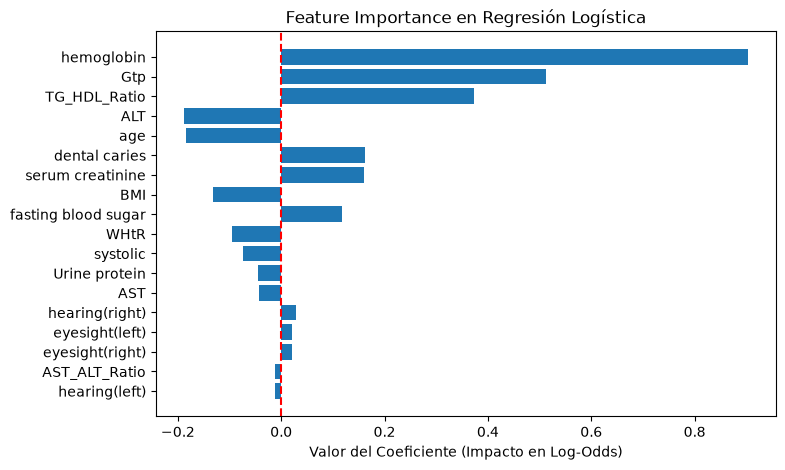

In [156]:
feature_names = pl[:1].fit_transform(X_train).columns  # O usar gs.best_estimator_.named_steps['CT1'].get_feature_names_out()
# 2. Crear DataFrame con los coeficientes
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': model.coef_[0],
    'Importancia_Absoluta': np.abs(model.coef_[0])
}).sort_values(by='Importancia_Absoluta', ascending=False)

print(importance_df)

# 3. Graficar la importancia con su signo
plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'][::-1], importance_df['Coeficiente'][::-1])
plt.xlabel("Valor del Coeficiente (Impacto en Log-Odds)")
plt.title("Feature Importance en Regresión Logística")
plt.axvline(x=0, color='red', linestyle='--')
plt.show()